## 📌 TL;DR: Rainfall Prediction Using Classification Models

This notebook focuses on preparing the dataset, training multiple classification models (like Logistic Regression, KNN, and Random Forest), and evaluating them using cross-validation. The main goal is to identify the best-performing model to predict whether it will rain or not.

🔍 Note: Extensive exploratory data analysis (EDA) is not the main focus here — this notebook emphasizes practical model building and evaluation.

🏁 The final model (Logistic Regression) is retrained on the full training set and used to predict rainfall on the test set.


In [ ]:
📌 

## 1. Import Libraries

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## 2. Load Data

In [109]:
train = pd.read_csv("/Users/titassaha/code/python/playground-series-s5e3/train.csv")
test = pd.read_csv("/Users/titassaha/code/python/playground-series-s5e3/test.csv")
sample = pd.read_csv("/Users/titassaha/code/python/playground-series-s5e3/sample_submission.csv")

train.drop(columns = 'id', inplace=True)
test.drop(columns = 'id', inplace = True)


In [110]:
train.head(2)

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1


In [111]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2190 entries, 0 to 2189
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   day            2190 non-null   int64  
 1   pressure       2190 non-null   float64
 2   maxtemp        2190 non-null   float64
 3   temparature    2190 non-null   float64
 4   mintemp        2190 non-null   float64
 5   dewpoint       2190 non-null   float64
 6   humidity       2190 non-null   float64
 7   cloud          2190 non-null   float64
 8   sunshine       2190 non-null   float64
 9   winddirection  2190 non-null   float64
 10  windspeed      2190 non-null   float64
 11  rainfall       2190 non-null   int64  
dtypes: float64(10), int64(2)
memory usage: 205.4 KB


In [112]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   day            730 non-null    int64  
 1   pressure       730 non-null    float64
 2   maxtemp        730 non-null    float64
 3   temparature    730 non-null    float64
 4   mintemp        730 non-null    float64
 5   dewpoint       730 non-null    float64
 6   humidity       730 non-null    float64
 7   cloud          730 non-null    float64
 8   sunshine       730 non-null    float64
 9   winddirection  729 non-null    float64
 10  windspeed      730 non-null    float64
dtypes: float64(10), int64(1)
memory usage: 62.9 KB


Modifying dataset with minor changes

In [113]:
train = train.rename(columns = {'temparature' : 'temperature'})
test = test.rename(columns = {'temparature':'temperature'})

print(f"Dimension of train data is {train.shape}")
print(f"Dimension of test data is {test.shape}")

Dimension of train data is (2190, 12)
Dimension of test data is (730, 11)


## 3. Handle Missing Data

In [114]:
print(f"Missing data train \n\n{train.isnull().sum()}")
print(f"\n\nMissing data test \n\n{test.isnull().sum()}")

Missing data train 

day              0
pressure         0
maxtemp          0
temperature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
sunshine         0
winddirection    0
windspeed        0
rainfall         0
dtype: int64


Missing data test 

day              0
pressure         0
maxtemp          0
temperature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
sunshine         0
winddirection    1
windspeed        0
dtype: int64


In [115]:
#filling missing value in wind direction
test['winddirection'].fillna(test['winddirection'].median(), inplace = True)

Checking correlation between rainfall and features

In [116]:
import scipy
from scipy.stats.stats import pearsonr

corr_df = pd.DataFrame()
p = []
feature_1 = []
feature_2 = []
correlation = []

for feat_1 in train.columns:
    if feat_1 not in ['rainfall']:
        feature_1.append(feat_1)
        corr, p_value = scipy.stats.pearsonr(train[feat_1], train['rainfall'])
        correlation.append(corr)
        p.append(p_value)

corr_df['feature_1'] = feature_1
corr_df['feature_2'] = 'rainfall'
corr_df['p_value']=p
corr_df['correlation']=correlation

corr_df.sort_values('correlation', ascending = False)

,feature_1,feature_2,p_value,correlation
7,cloud,rainfall,6.744508e-254,0.641191
6,humidity,rainfall,6.194524e-112,0.454213
10,windspeed,rainfall,1.630871e-07,0.111625
5,dewpoint,rainfall,1.230212e-04,0.081965
0,day,rainfall,9.827626e-01,-0.000462
9,winddirection,rainfall,7.455205e-01,-0.006939
4,mintemp,rainfall,2.092534e-01,-0.026841
3,temperature,rainfall,2.012137e-02,-0.049660
1,pressure,rainfall,1.956243e-02,-0.049886
2,maxtemp,rainfall,2.032564e-04,-0.079304


Text(0.5, 1.0, 'Correlation: Rain with all features')

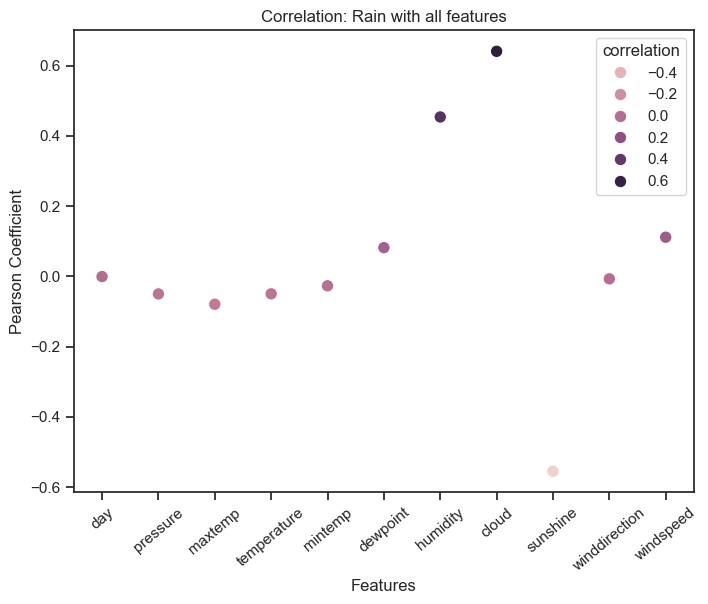

In [117]:
plt.figure(figsize=(8,6))
sns.set_theme(style = "ticks")

sns.scatterplot(data = corr_df, x = "feature_1", y = "correlation", s=80,  hue = "correlation")
plt.tick_params(axis='x', labelrotation=40)
plt.xlabel("Features")
plt.ylabel("Pearson Coefficient")
plt.title("Correlation: Rain with all features")

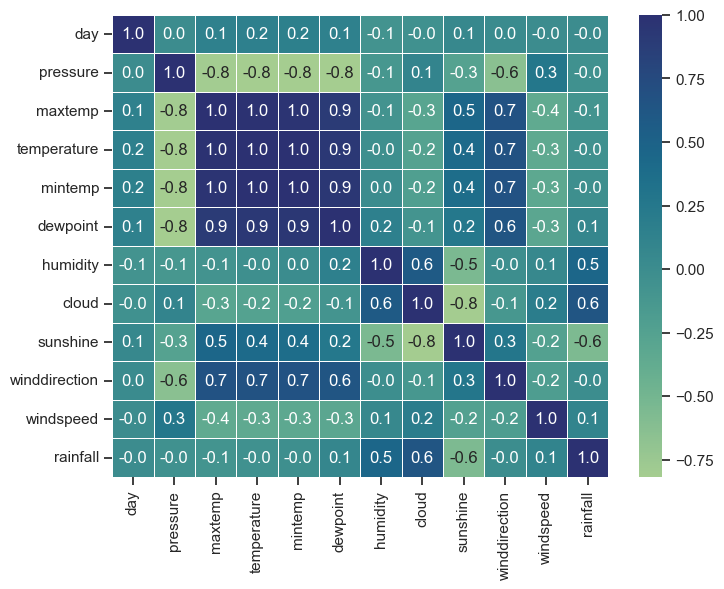

In [118]:
plt.figure(figsize = (8,6))
ax = sns.heatmap(train.corr(numeric_only = True), annot = True, fmt = ".1f", linewidth = 0.5, cmap="crest")

Rainfall has strongest positive correlation with :
- cloud
- humidity

and, strongest negative correlation with:
- sunshine

## 4. Model Evaluation

I plan to predict rainfall using the best of three models - logitic regresison, knn classifier, and random forest. 

In [119]:
#checking the distribution of rainfall which does not have a balance
train['rainfall'].value_counts()

rainfall
1    1650
0     540
Name: count, dtype: int64

In [120]:
from sklearn import metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, 
mean_absolute_error, mean_squared_error)
from sklearn.model_selection import KFold


kf = KFold(n_splits = 5, shuffle = True, random_state = 42)

def model_kfold(model, x , y , kf):

    acc_list, prec_list, rec_list, f1_list, auc_list = [], [], [], [], []
    mae_list, mse_list, rmse_list = [], [], []

    for train_index, test_index in kf.split(x):
        x_train, x_test = x.iloc[train_index], x.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
        y_prob = model.predict_proba(x_test)[:,1]

        #classification metrics
        acc_list.append(round(accuracy_score(y_test, y_pred) ,4))
        prec_list.append(round(precision_score(y_test, y_pred), 4))
        rec_list.append(round(recall_score(y_test, y_pred),4))
        f1_list.append(round(f1_score(y_test, y_pred),4))
        auc_list.append(round(roc_auc_score(y_test, y_pred),4))
        
        #regression metrics
        mae_list.append(round( mean_absolute_error(y_test, y_pred),4))
        mse_val = round(mean_squared_error(y_test, y_pred),4)
        mse_list.append(mse_val)
        rmse_list.append(mse_val)

    model_df = {"accuracy": acc_list,
                "precision": prec_list,
                "recall" : rec_list,
                "f1_score": f1_list,
                "roc_auc" : auc_list,
                "mae" : mae_list,
                "mse": mse_list,
                "rmse" : rmse_list}
    model_df = pd.DataFrame(model_df)

    return model_df


In [121]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

x = train.drop('rainfall', axis = 1)
y = train[['rainfall']] #double square brackets ensure y remains a dataframe, single would make it a series

#logistic regression
lr_model = LogisticRegression()
lr_results = model_kfold(lr_model, x, y, kf)

#knn
knn_model = KNeighborsClassifier(n_neighbors = 10)
knn_results = model_kfold(knn_model, x, y, kf)

#random forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_results = model_kfold(rf_model, x, y, kf)

In [122]:
#print average result from the model results

def print_avg_scores(model_results, model):
    print(f"\nAverage of Metrics for {model} :")

    for metrics, values in model_results.items():
        print(f"{metrics} : {round(np.mean(values),2)}")


print_avg_scores(lr_results, lr_model)
print_avg_scores(knn_results, knn_model)
print_avg_scores(rf_results, rf_model)


Average of Metrics for LogisticRegression() :
accuracy : 0.87
precision : 0.89
recall : 0.94
f1_score : 0.91
roc_auc : 0.79
mae : 0.13
mse : 0.13
rmse : 0.13

Average of Metrics for KNeighborsClassifier(n_neighbors=10) :
accuracy : 0.85
precision : 0.87
recall : 0.93
f1_score : 0.9
roc_auc : 0.76
mae : 0.15
mse : 0.15
rmse : 0.15

Average of Metrics for RandomForestClassifier(random_state=42) :
accuracy : 0.86
precision : 0.89
recall : 0.93
f1_score : 0.91
roc_auc : 0.79
mae : 0.14
mse : 0.14
rmse : 0.14


Logistic regression scores better than other models, therefore, we'll  proceed with this. 

Before predicting the test set, let's take a look at at the confusion matrix by testing on the training set.

In [123]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

final_model= LogisticRegression()
final_model.fit(x_train, y_train)

y_pred = final_model.predict(x_test)
y_prob = final_model.predict_proba(x_test)[:,1]


print("Confusion Matrix\n", confusion_matrix(y_test, y_pred))

Confusion Matrix
 [[ 74  45]
 [ 20 299]]


## 5. Prediction and Submission

In [126]:

y_test_submission = pd.read_csv("/Users/titassaha/code/python/playground-series-s5e3/test.csv") #has 'id'

final_model.fit(x, y)
y_submission_pred = final_model.predict(test)
y_submission_prob = final_model.predict_proba(test)[:, 1]

submission_df = pd.DataFrame( {
    'id': y_test_submission['id'],
    'rainfall' : y_submission_pred
})

submission_df.to_csv("/Users/titassaha/code/python/playground-series-s5e3/submission.csv", index=False)